В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [17]:
import pandas as pd
import time
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

import matplotlib.pyplot as plt

from hw_2_3_1_helpers.process_bank_churn import preprocess_data, preprocess_new_data

In [2]:
train_df = pd.read_csv("../../data/data_kaggle_01/train.csv")
test_df = pd.read_csv("../../data/data_kaggle_01/test.csv")
sample_submission = pd.read_csv("../../data/data_kaggle_01/sample_submission.csv")

In [3]:
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(train_df, scaler_numeric=True)

X_test = preprocess_new_data(test_df, input_cols=input_cols, scaler=scaler)

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [5]:
# Створюємо модель kNN з параметрами за замовченням
knn = KNeighborsClassifier()

# Навчання на тренувальному наборі
knn.fit(X_train, y_train)

# Прогноз на тренувальному і валідаційному наборах
y_train_pred = knn.predict_proba(X_train)[:, 1]
y_val_pred = knn.predict_proba(X_val)[:, 1]

# Обчислення AUROC
train_auc = roc_auc_score(y_train, y_train_pred)
val_auc = roc_auc_score(y_val, y_val_pred)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9617
Validation AUROC: 0.8743


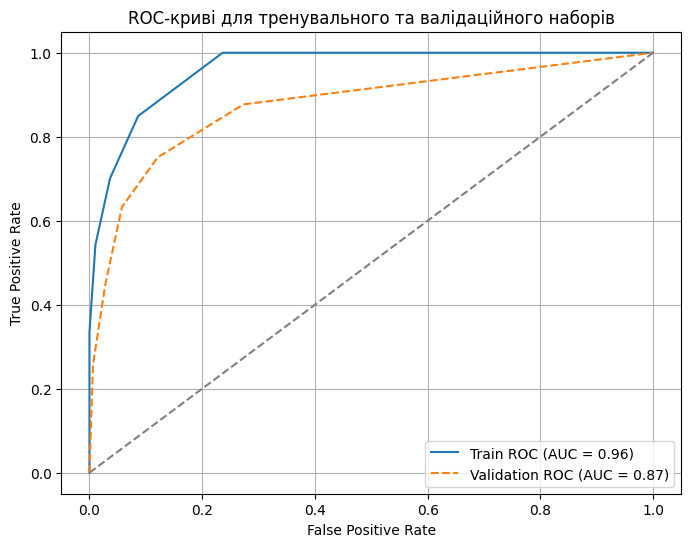

In [10]:
# Обчислення ROC-кривих
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred)

# Побудова графіку
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {train_auc:.2f})")
plt.plot(fpr_val, tpr_val, label=f"Validation ROC (AUC = {val_auc:.2f})", linestyle="--")
plt.plot([0, 1], [0, 1], color='gray', linestyle='dashed')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-криві для тренувального та валідаційного наборів")
plt.legend()
plt.grid(True)
plt.show()

**Висновок**
Модель kNN з параметрами за замовчуванням демонструє:

Високу якість на тренувальному наборі (майже 0.96) — тобто модель добре "запам’ятовує" тренувальні приклади.

Трохи нижчу якість на валідаційному наборі (0.87) — свідчить про легке переобучення.

Модель має високу дисперсію (high variance). Це типовий сценарій для kNN, особливо з малим значенням k.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [12]:
# Модель
knn = KNeighborsClassifier()

# Сітка гіперпараметрів
param_grid = {
    'n_neighbors': list(range(1, 31))
}

# GridSearchCV з AUROC як метрикою
grid = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Пошук на тренувальних даних
grid.fit(X_train, y_train)

# Найкраща модель
knn_best = grid.best_estimator_

# Вивід найкращого параметра
print(f"Найкраще n_neighbors: {grid.best_params_['n_neighbors']}")

Найкраще n_neighbors: 28


In [13]:
# Прогноз і метрика AUROC
y_train_best = knn_best.predict_proba(X_train)[:, 1]
y_val_best = knn_best.predict_proba(X_val)[:, 1]

train_auc_best = roc_auc_score(y_train, y_train_best)
val_auc_best = roc_auc_score(y_val, y_val_best)

print(f"Train AUROC (best): {train_auc_best:.4f}")
print(f"Validation AUROC (best): {val_auc_best:.4f}")

Train AUROC (best): 0.9362
Validation AUROC (best): 0.9156


**Висновок**

Модель після підбору гіперпараметрів (з n_neighbors=28) працює краще, ніж базова модель. Вона має нижчу дисперсію та вищу якість на валідації.
Різниця між train/val стала меншою → модель стала стабільнішою та краще узагальнює.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [15]:
# Ініціалізація моделі
dt = DecisionTreeClassifier(random_state=42)

# Сітка гіперпараметрів
param_grid = {
    'max_depth': list(range(1, 21, 2)),
    'max_leaf_nodes': list(range(2, 11))
}

# Вимір часу
start_time = time.time()

# GridSearchCV
grid_dt = GridSearchCV(dt, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train, y_train)

end_time = time.time()
print(f"Час пошуку гіперпараметрів: {end_time - start_time:.2f} секунд")

# Найкраща модель
dt_best = grid_dt.best_estimator_
print("Найкращі параметри:", grid_dt.best_params_)

Час пошуку гіперпараметрів: 2.47 секунд
Найкращі параметри: {'max_depth': 5, 'max_leaf_nodes': 10}


In [16]:
y_train_dt = dt_best.predict_proba(X_train)[:, 1]
y_val_dt = dt_best.predict_proba(X_val)[:, 1]

train_auc_dt = roc_auc_score(y_train, y_train_dt)
val_auc_dt = roc_auc_score(y_val, y_val_dt)

print(f"Train AUROC (tree): {train_auc_dt:.4f}")
print(f"Validation AUROC (tree): {val_auc_dt:.4f}")

Train AUROC (tree): 0.9015
Validation AUROC (tree): 0.9002


**Висновок**

- kNN має трохи вищу валідаційну метрику – отже, він показав кращий результат на цьому наборі.

Але дерево рішень:

- працює швидше в інференсі;

- інтерпретується краще;

- і в нашому випадку має дуже балансовані AUROC train/val, тобто добре узагальнює.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [19]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [20]:
# Модель з фіксованим random_state
dt_rs = DecisionTreeClassifier(random_state=42)

# RandomizedSearchCV
from time import time
start = time()

random_search = RandomizedSearchCV(
    dt_rs,
    param_distributions=params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)

end = time()
print(f"Час пошуку: {end - start:.2f} секунд")

# Найкраща модель
dt_random_search_best = random_search.best_estimator_
print("Найкращі параметри:", random_search.best_params_)

Час пошуку: 1.00 секунд
Найкращі параметри: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


In [21]:
y_train_rs = dt_random_search_best.predict_proba(X_train)[:, 1]
y_val_rs = dt_random_search_best.predict_proba(X_val)[:, 1]

train_auc_rs = roc_auc_score(y_train, y_train_rs)
val_auc_rs = roc_auc_score(y_val, y_val_rs)

print(f"Train AUROC (RandomSearch): {train_auc_rs:.4f}")
print(f"Validation AUROC (RandomSearch): {val_auc_rs:.4f}")

Train AUROC (RandomSearch): 0.9169
Validation AUROC (RandomSearch): 0.9166


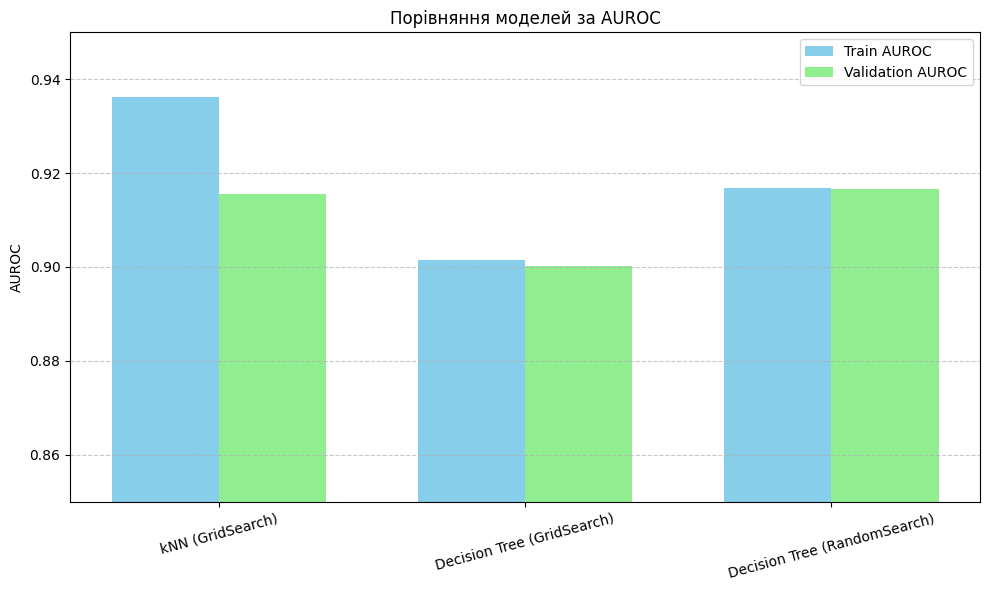

In [23]:
models = ['kNN (GridSearch)', 'Decision Tree (GridSearch)', 'Decision Tree (RandomSearch)']

train_auc = [0.9362, 0.9015, 0.9169]
val_auc = [0.9156, 0.9002, 0.9166]

x = range(len(models))

plt.figure(figsize=(10, 6))
plt.bar(x, train_auc, width=0.35, label='Train AUROC', align='center', color='skyblue')
plt.bar([i + 0.35 for i in x], val_auc, width=0.35, label='Validation AUROC', align='center', color='lightgreen')

plt.xticks([i + 0.175 for i in x], models, rotation=15)
plt.ylim(0.85, 0.95)
plt.ylabel("AUROC")
plt.title("Порівняння моделей за AUROC")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Висновок**

- RandomizedSearchCV дав найкращу модель по AUROC на валідації, навіть трохи краще за kNN.

-  AUROC train ≈ val → модель добре узагальнює.

- Більш гнучка сітка гіперпараметрів (в RandomizedSearch) дозволила знайти оптимальні налаштування, які не були розглянуті у GridSearch.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [25]:
X_test = preprocess_new_data(
    test_df,
    input_cols=input_cols,
    scaler=scaler,
    reference_columns=X_train.columns  # дуже важливо!
)

test_pred_proba = dt_random_search_best.predict_proba(X_test)[:, 1]
sample_submission['Exited'] = test_pred_proba

In [26]:
print(sample_submission.head())

      id    Exited
0  15000  0.039301
1  15001  0.012115
2  15002  0.203947
3  15003  0.569848
4  15004  0.082171


In [29]:
sample_submission.to_csv('data_hw_2_4/submission_dt_random_search.csv', index=False)


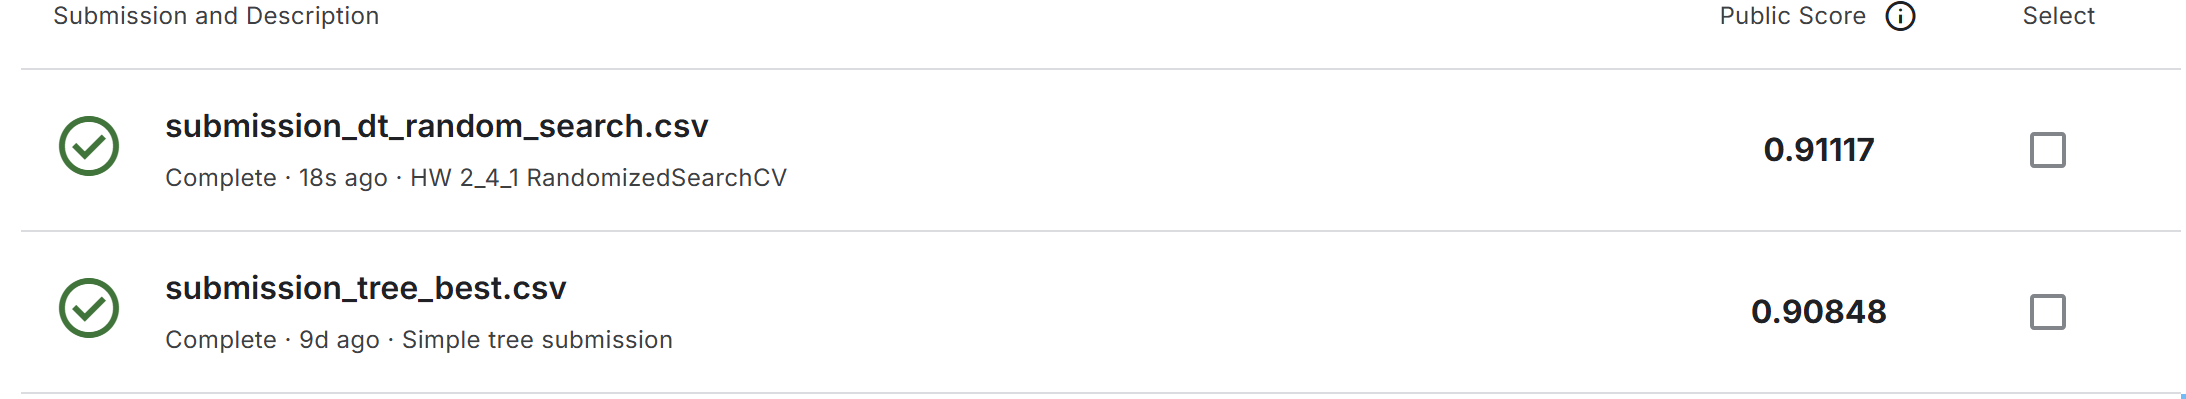

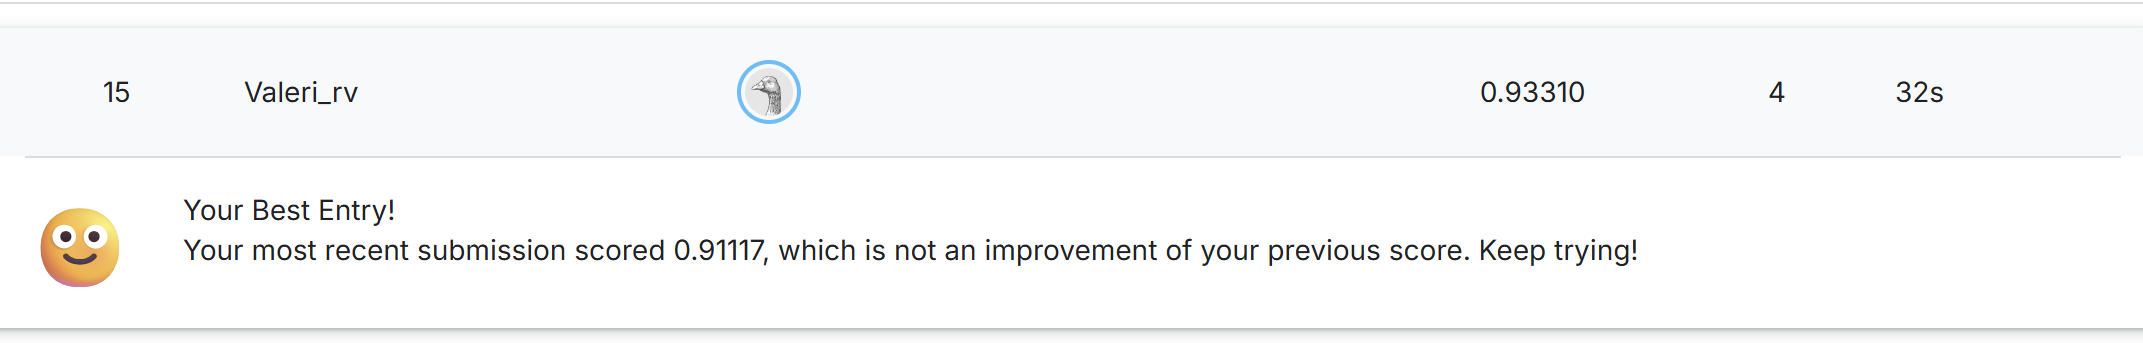